In [ ]:
pip install yfinance pandas scikit-learn nltk matplotlib seaborn transformers


In [6]:
import pandas as pd
import re

# Define column names
column_names = ['sentiment','ID', 'timestamp', 'query', 'user', 'text']

# Load the dataset with the correct column names
tweets = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",
                     encoding='ISO-8859-1', names=column_names, header=None)

# Preprocess text: remove non-alphanumeric characters, lowercase, etc.
tweets['cleaned_text'] = tweets['text'].apply(lambda x: ' '.join(re.sub(r'[^a-zA-Z0-9\s]', '', x).split()))

# Display the first few rows to confirm
print(tweets.head())

   sentiment          ID                     timestamp     query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  \
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1    scotthamilton  is upset that he can't update his Facebook by ...   
2         mattycus  @Kenichan I dived many times for the ball. Man...   
3          ElleCTF    my whole body feels itchy and like its on fire    
4           Karoli  @nationwideclass no, it's not behaving at all....   

                                        cleaned_text  
0  switchfoot httptwitpiccom2y1zl Awww thats a bu...  
1  is upset that he cant update his Facebo

In [7]:
# Use only 100,000 rows to train for now
tweets_sampled = tweets.sample(n=100000, random_state=42)

X = tweets_sampled['cleaned_text']
y = tweets_sampled['sentiment']

In [8]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

# Preprocess the 'cleaned_text' if needed (e.g., remove non-alphanumeric characters, lower case, etc.)
tweets_sampled['cleaned_text'] = tweets_sampled['text'].apply(lambda x: ' '.join(re.sub(r'[^a-zA-Z0-9\s]', '', x).split()))

# Step 1: Split the data into train and test sets
X = tweets_sampled['cleaned_text']  # Feature: the cleaned text of the tweets
y = tweets_sampled['sentiment']     # Target: sentiment labels (positive, negative, neutral)

In [9]:
# Splitting the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Step 2: Create the model pipeline (TF-IDF + Naive Bayes)
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

In [11]:
# Step 3: Train the model on the training data
model.fit(X_train, y_train)

Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer()),
                ('multinomialnb', MultinomialNB())])

In [12]:
# Step 4: Make predictions on the test data
predictions = model.predict(X_test)

In [13]:
# Step 5: Evaluate the model (print performance metrics)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.72      0.83      0.77      9995
           4       0.80      0.68      0.73     10005

    accuracy                           0.75     20000
   macro avg       0.76      0.75      0.75     20000
weighted avg       0.76      0.75      0.75     20000



In [14]:
# Convert timestamp to datetime
tweets['date'] = pd.to_datetime(tweets['timestamp'], errors='coerce')

<ipython-input-14-e1db6e9490d5>:2: FutureWarning: Parsed string "Mon Apr 06 22:19:45 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  tweets['date'] = pd.to_datetime(tweets['timestamp'], errors='coerce')


In [15]:
# Aggregate sentiment by date
daily_sentiment = tweets.groupby(tweets['date'].dt.date)['sentiment'].mean().reset_index()
daily_sentiment.columns = ['Date', 'Avg_Sentiment']
print(daily_sentiment.head())


         Date  Avg_Sentiment
0  2009-04-06       2.302381
1  2009-04-07       2.348102
2  2009-04-17       2.386511
3  2009-04-18       2.337777
4  2009-04-19       2.336015


In [ ]:
# Download stock data with multi-level columns
import yfinance as yf
stock_data = yf.download('SPY', start='2009-04-06', end='2009-06-25', group_by='ticker')

# Flatten the column MultiIndex
stock_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in stock_data.columns]

# Reset index to move 'Date' to a column
stock_data.reset_index(inplace=True)

# Convert 'Date' to just date (not datetime)
stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.date


In [17]:
print(stock_data.columns.tolist())


['Date', 'SPY_Open', 'SPY_High', 'SPY_Low', 'SPY_Close', 'SPY_Volume']


In [ ]:
# Ensure daily_sentiment has proper date format too
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date']).dt.date

# Merge stock data and sentiment
merged_df = pd.merge(stock_data, daily_sentiment, on='Date', how='left')
merged_df['Avg_Sentiment'].fillna(method='ffill', inplace=True)


In [ ]:
# Compute stock returns (optional)
merged_df['Daily_Return'] = merged_df['SPY_Close'].pct_change()

# Display final merged data
print(merged_df[['Date', 'Avg_Sentiment', 'SPY_Close', 'Daily_Return']].head(10))

In [ ]:
print(stock_data['Date'].min(), stock_data['Date'].max())
print(daily_sentiment['Date'].min(), daily_sentiment['Date'].max())


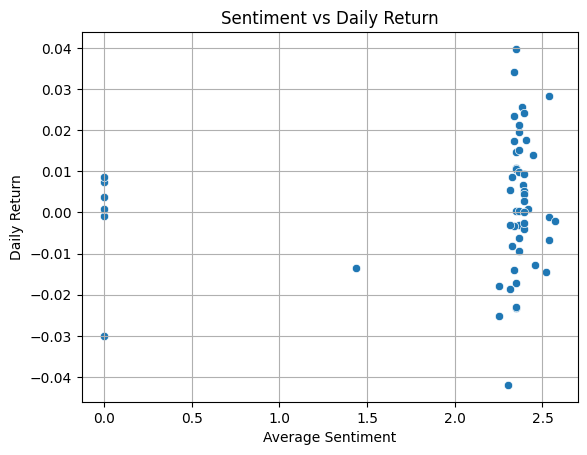

Correlation: 0.10553065210274326


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation plot
sns.scatterplot(data=merged_df, x='Avg_Sentiment', y='Daily_Return')
plt.title("Sentiment vs Daily Return")
plt.xlabel("Average Sentiment")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

# Correlation coefficient
print("Correlation:", merged_df['Avg_Sentiment'].corr(merged_df['Daily_Return']))
